# Bookstore Customer Analytics Project(Notebook 2)
## Notebook 2: Exploratory Data Analysis (EDA), Feature Engineering and Predictive Modeling
### Project Overview

This notebook builds upon the cleaned dataset generated in Notebook 1 (Readers are encouraged to review the first notebook for details on the data cleaning process before proceeding). With the dataset cleaned and prepared, the focus now shifts to exploring the data, engineering meaningful features, and developing predictive machine learning models.

The notebook begins with Exploratory Data Analysis (EDA) to identify patterns, relationships, and trends within the dataset. Insights gained from the EDA help guide feature engineering and provide a better understanding of the factors that may influence customer spending. The data is then preprocessed for machine learning through feature encoding, train-test splitting, and feature scaling before training and evaluating multiple regression models.

---

### Objectives

The main objectives of this notebook are to:

- Perform Exploratory Data Analysis (EDA) to uncover patterns and relationships within the customer data.
- Engineer meaningful features that may improve model performance.
- Prepare the dataset for machine learning through preprocessing techniques such as encoding and feature scaling.
- Train and evaluate multiple regression models to predict customer total spending.
- Compare model performance using R² Score, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).
- Identify the best-performing model and discuss the strengths and limitations of the predictive approach.
  
---

### Workflow
The notebook follows the workflow below:
1. Exploratory Data Analysis (EDA)
2. Feature Engineering
3. Data Preprocessing
4. Train-Test Split
5. Feature Scaling
6. Model Training
7. Model Evaluation and Comparison
8. Conclusion

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [23]:
df = pd.read_csv("cleaned_bookstore_customers.csv")

In [24]:
df.head()

,customer_id,signup_date,home_store,annual_visits,online_ratio,ltv_estimate,first_purchase_date,last_purchase_date,region,loyalty_member,total_purchases,total_spent,avg_purchase_value,visits_2023,has_escalation,escalation_reason,customer_rating
0,1405,NaN,YYC-SE,16.0,0.00,256.00,NaN,2023-08-29,Calgary Se,Unknown,76.0,6851.62,89.12,15.0,No,No Escalation,3.8
1,6892,2023-02-25,YYC-DT,9.0,3.25,94.82,2023-02-25,2024-04-12,Calgary Downtown,No,22.0,908.00,64.92,8.0,No,No Escalation,4.0
2,7461,2022-08-22,YYC-NW,10.0,4.26,28.45,2022-08-22,2023-08-13,Calgary Nw,Yes,25.0,2300.92,90.15,14.0,No,No Escalation,4.9
3,9324,2023-12-10,YYC-DT,11.0,0.00,201.00,2023-12-10,2024-10-23,Calgary Downtown,No,11.0,906.38,91.43,13.0,Yes,Unknown,3.3
4,6675,2024-11-27,YYC-NW,8.0,0.00,467.25,2024-11-27,2024-01-01,Calgary Nw,No,2.0,46.82,46.76,5.0,No,No Escalation,3.5


## Dataset Overview

Before beginning the analysis, we inspect the dataset structure, data types, and summary statistics.

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          12000 non-null  int64  
 1   signup_date          11076 non-null  str    
 2   home_store           12000 non-null  str    
 3   annual_visits        12000 non-null  float64
 4   online_ratio         12000 non-null  float64
 5   ltv_estimate         12000 non-null  float64
 6   first_purchase_date  11032 non-null  str    
 7   last_purchase_date   10990 non-null  str    
 8   region               12000 non-null  str    
 9   loyalty_member       12000 non-null  str    
 10  total_purchases      12000 non-null  float64
 11  total_spent          12000 non-null  float64
 12  avg_purchase_value   12000 non-null  float64
 13  visits_2023          12000 non-null  float64
 14  has_escalation       12000 non-null  str    
 15  escalation_reason    12000 non-null  str    
 1

In [26]:
df.describe()

,customer_id,annual_visits,online_ratio,ltv_estimate,total_purchases,total_spent,avg_purchase_value,visits_2023,customer_rating
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,10.458083,0.913161,150.031881,27.302167,1669.042564,60.790216,8.770833,3.946725
std,3464.24595,5.089555,1.239719,93.626529,22.592880,1591.764662,22.360642,4.907867,0.608049
min,1.00000,0.000000,0.000000,2.880000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,6.000000,0.000000,81.222500,10.000000,528.187500,43.987500,5.000000,3.600000
50%,6000.50000,11.000000,0.330000,131.050000,21.000000,1183.920000,60.650000,8.000000,4.000000
75%,9000.25000,15.000000,1.510000,199.382500,39.000000,2293.967500,76.870000,12.000000,4.300000
max,12000.00000,22.000000,12.680000,800.190000,119.000000,17480.300000,224.320000,24.000000,6.500000


In [27]:
df.shape

(12000, 17)

In [28]:
df.nunique()

customer_id            12000
signup_date             2163
home_store                 4
annual_visits             23
online_ratio             568
ltv_estimate            9783
first_purchase_date     2160
last_purchase_date      1747
region                     4
loyalty_member             3
total_purchases          119
total_spent            10790
avg_purchase_value      5792
visits_2023               25
has_escalation             3
escalation_reason          7
customer_rating           66
dtype: int64

# Exploratory Data Analysis (EDA)

The goal of this section is to uncover patterns, trends, and relationships within the bookstore customer dataset through descriptive statistics and visualizations.

## 1. Univariate Analysis of Customer Profile (Categorical Variables)

This section explores categorical features such as customer region, store distribution, loyalty status, and escalation reasons to understand customer segmentation and behavior patterns.

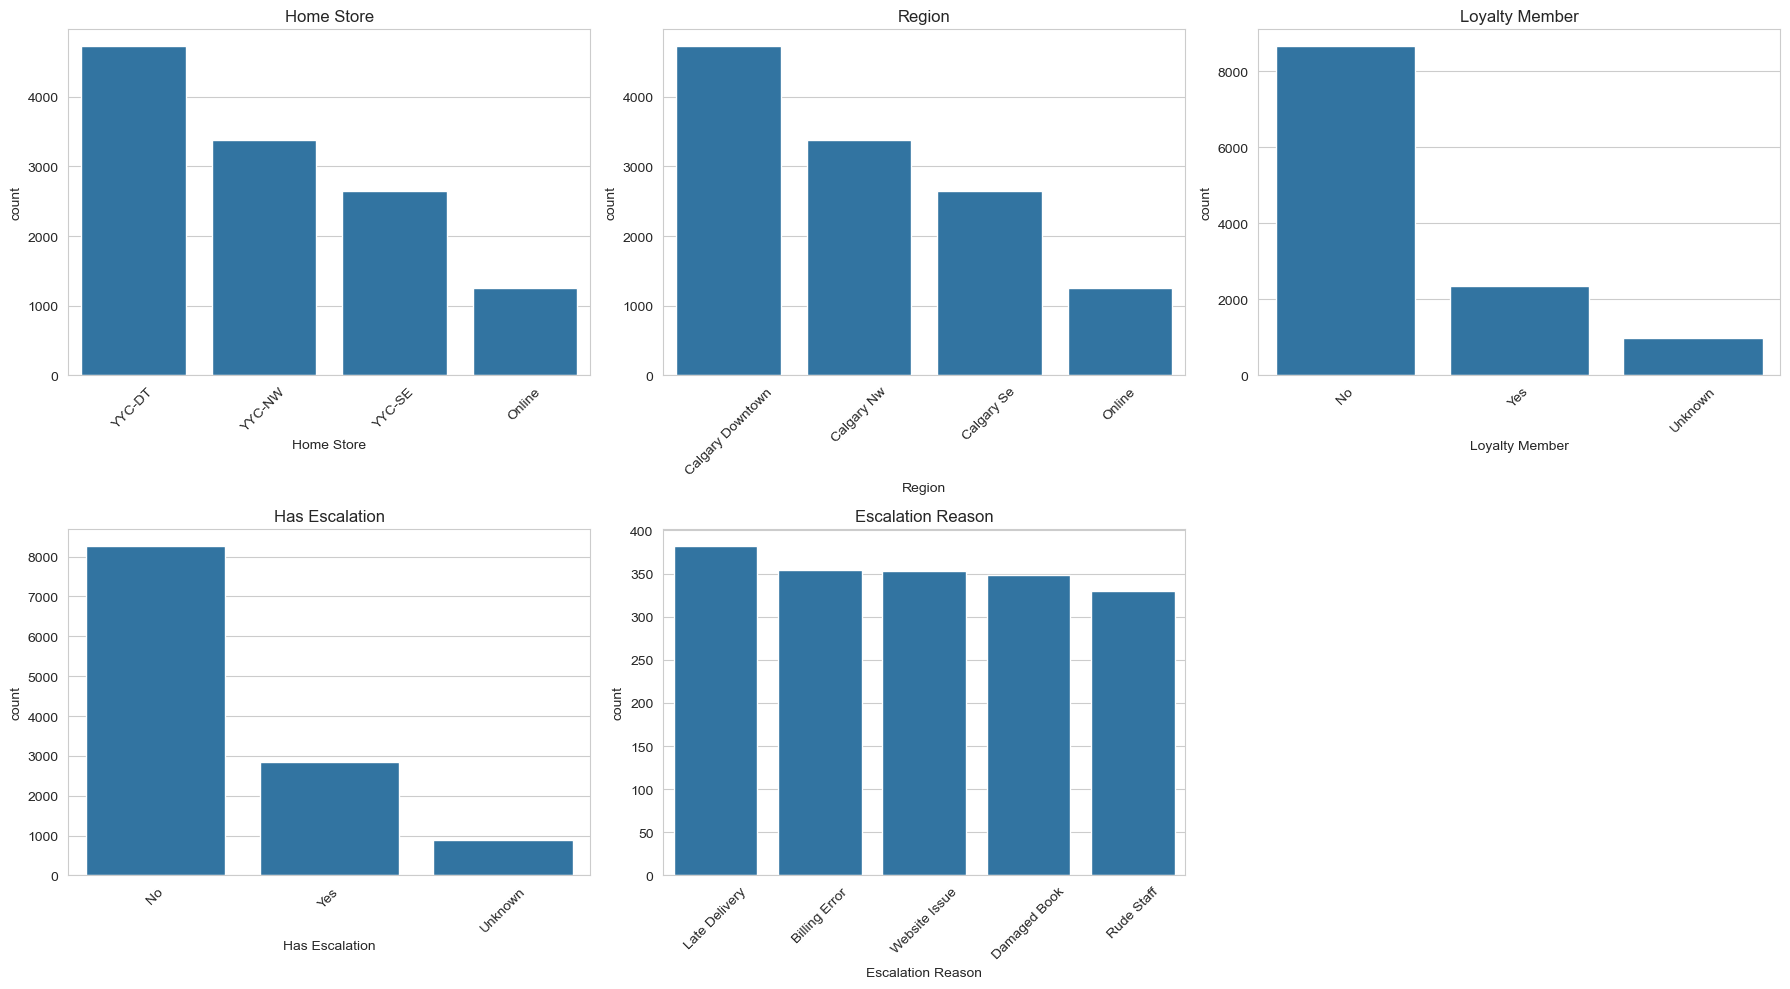

In [29]:
cat_cols = ['home_store', 'region', 'loyalty_member', 'has_escalation', 'escalation_reason']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    
    if col == 'escalation_reason':
        temp = df[~df[col].isin(['No Escalation', 'Unknown'])]
        order = temp[col].value_counts().index
        sns.countplot(data=temp, x=col, order=order, ax=ax)
        ax.set_title(col.replace('_', ' ').title())
        ax.set_xlabel(col.replace('_',' ').title())
        ax.tick_params(axis='x', rotation=45)
    else:    
        order = df[col].value_counts().index
        sns.countplot(data=df, x=col, order=order, ax=ax)
    
        ax.set_title(col.replace('_', ' ').title())
        ax.set_xlabel(col.replace('_',' ').title())
        ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Interpretation

The distribution of the categorical variables provides an overview of customer characteristics and operational patterns across the bookstore.

The home store distribution indicates that YYC-DT serves the largest proportion of customers, followed by YYC-NW, YYC-SE, and the Online store. This suggests that the downtown branch has the highest customer activity, while online transactions account for the smallest share of the customer base.

A similar pattern is observed in the region variable, where Calgary Downtown contains the highest number of customers, followed by Calgary NW, Calgary SE, and Online. This consistency suggests that customer distribution across regions closely aligns with the distribution of their preferred home stores.

The loyalty_member variable shows that non-members substantially outnumber loyalty program members. This may indicate an opportunity for the business to improve customer retention and engagement through increased loyalty program participation.

Likewise, the has_escalation variable shows that most customers did not experience an escalation, while a much smaller proportion reported customer service issues. This suggests that escalations are relatively infrequent within the dataset.

Among customers who experienced an escalation, Late Delivery was the most common reason, while Rude Staff occurred least frequently. However, the frequencies of the different escalation reasons are relatively similar, indicating that customer complaints are distributed across multiple issue types rather than being dominated by a single recurring problem.

Overall, the categorical variables reveal a customer base concentrated around the downtown location, relatively low participation in the loyalty program, a low overall escalation rate, and a fairly balanced distribution of escalation reasons.

## 2. Univariate Analysis of Customer Value (Numerical Variables)

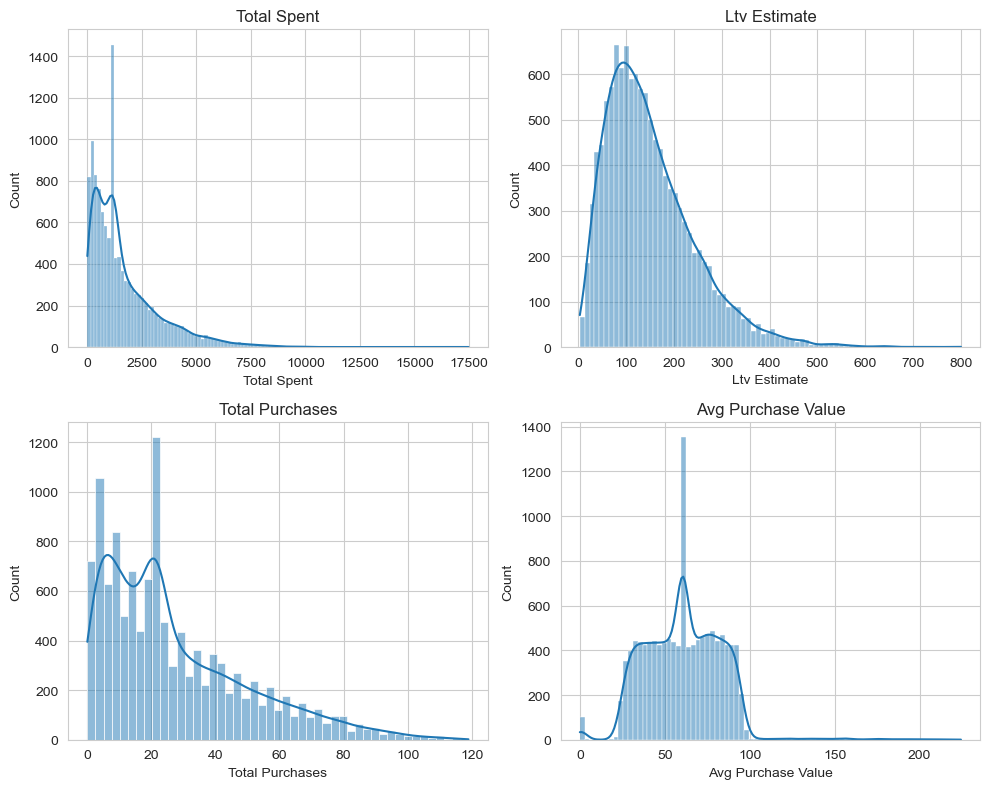

In [30]:
num_cols = ['total_spent', 'ltv_estimate', 'total_purchases', 'avg_purchase_value']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(col.replace('_',' ').title())

for ax in axes[len(num_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Interpretation

The numerical variables provide insight into customer purchasing behaviour and spending patterns.

The distribution of total spent is positively skewed, with most customers spending relatively lower amounts and fewer customers making substantially higher purchases. A noticeable concentration of observations is present within the lower spending range, indicating that the majority of customers fall into this spending bracket.

Similarly, total purchases exhibits a positively skewed distribution, suggesting that while most customers make relatively few purchases, a smaller number of customers make purchases much more frequently.

The LTV estimate also shows a positively skewed distribution, reflecting that most customers have moderate estimated lifetime values, while a smaller proportion are expected to generate significantly higher long-term value.

The average purchase value displays a roughly unimodal distribution with a prominent peak near the centre. This concentration of values is likely influenced by the earlier median imputation, where missing values were replaced with the median, resulting in many observations sharing the same value.

Overall, the numerical variables indicate that customer spending behaviour is not evenly distributed. Most customers contribute moderate spending and purchasing activity, while a smaller group accounts for substantially higher values. Additionally, the visible concentration around the median highlights the effect of the chosen missing-value imputation strategy.

## 3. Univariate Analysis of Customer Engagement (Numerical Variables)

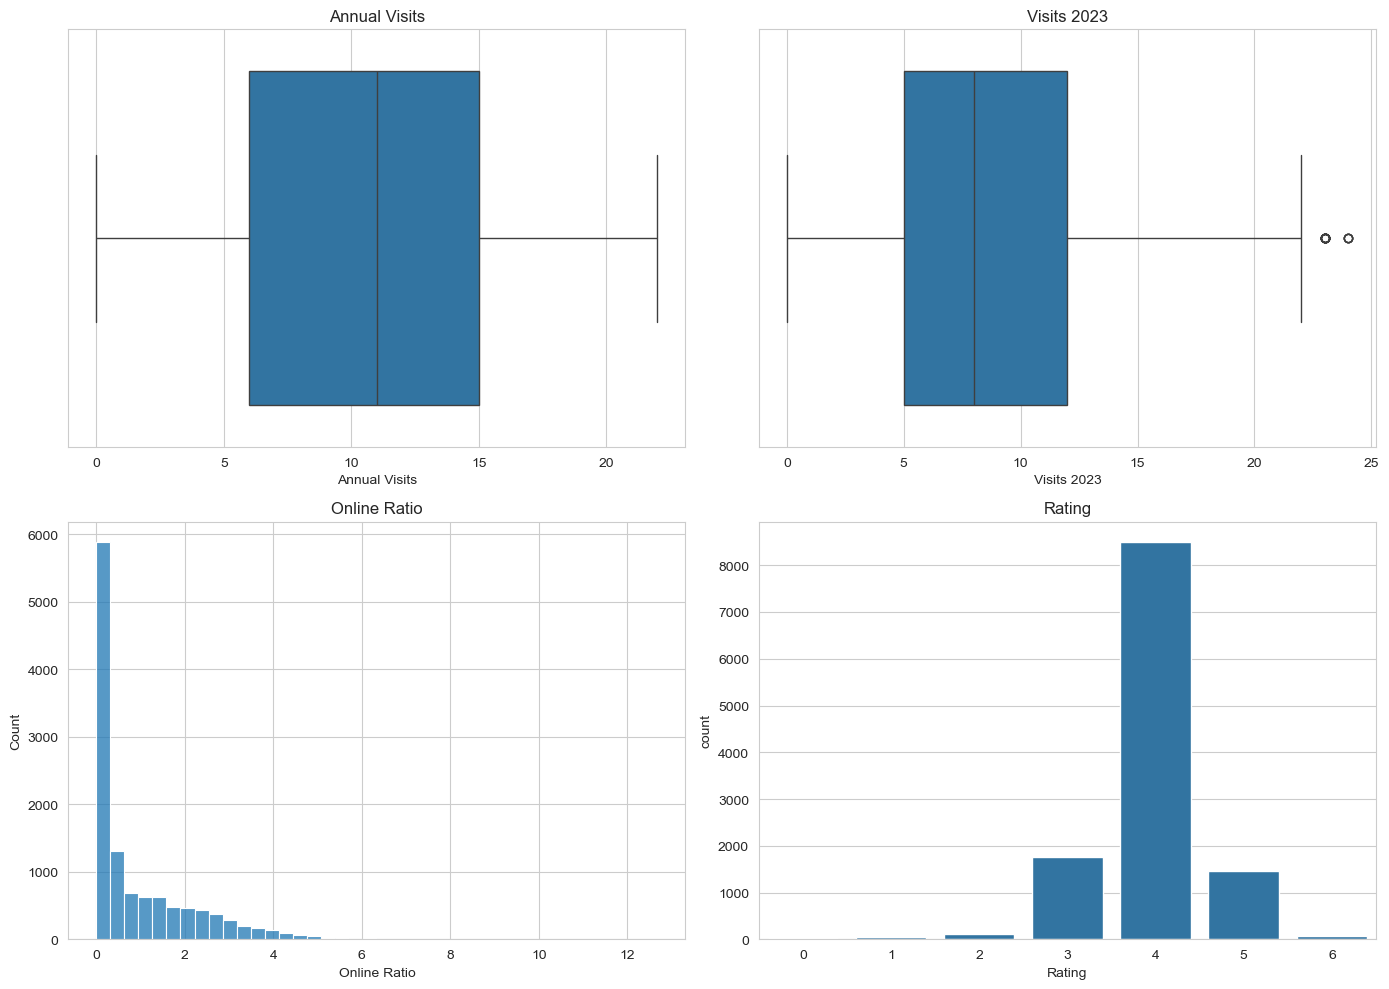

In [31]:
df['rating'] = df['customer_rating'].round().astype(int)
num_cols = ['annual_visits', 'visits_2023', 'online_ratio', 'rating']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):

    if col == 'rating':
        order = sorted(df[col].unique())
        sns.countplot(data=df, x=col, order=order, ax=ax)
        
    elif col == 'online_ratio':
        sns.histplot(df['online_ratio'], bins=40, ax=ax)
        
    else:
         sns.boxplot(x=df[col], ax=ax)
        
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(col.replace('_',' ').title())
    
plt.tight_layout()
plt.show()

### Interpretation

The customer engagement variables provide insight into customer activity, purchasing channels, and satisfaction levels.

The annual visits boxplot shows that most customers make a moderate number of visits each year, with the middle 50% of observations concentrated within a relatively narrow range. The distribution appears slightly positively skewed, indicating that while most customers visit at a moderate frequency, a smaller number make substantially more visits. No extreme outliers are evident, suggesting that annual visit behaviour is relatively consistent across the customer base.

The visits in 2023 boxplot shows that most customers recorded a moderate number of visits during the year, with the middle 50% of observations concentrated between approximately 5 and 12 visits. The distribution is positively skewed, as evidenced by the longer upper whisker and several high-value outliers. These outliers represent customers who visited the bookstore considerably more often than the majority, indicating the presence of a small group of highly engaged customers.

The online ratio distribution is positively skewed, with a large concentration of customers having low online purchasing ratios. This suggests that most customers primarily shop in physical stores, while a smaller proportion rely heavily on online purchases.

The customer ratings are concentrated around higher values, with a rating of 4 occurring most frequently, followed by 3 and 5. Very few customers gave ratings of 2 or 6, indicating that customer satisfaction is generally positive, with relatively few extremely low or unusually high ratings.

Overall, these variables suggest that customers exhibit moderate engagement with the business, predominantly shop through physical locations, and generally report favourable experiences based on their ratings.

# Bivariate Analysis

## 1. Numerical vs Numerical

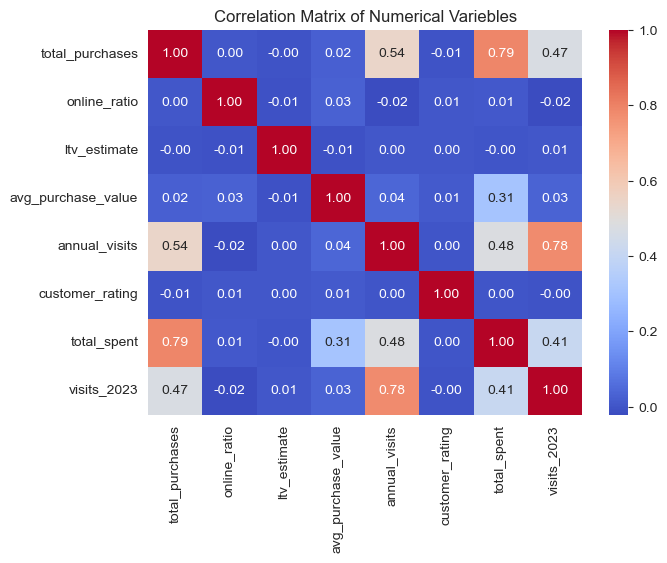

In [32]:
num_cols = ['total_purchases', 'online_ratio', 'ltv_estimate', 'avg_purchase_value',
            'annual_visits', 'customer_rating', 'total_spent', 'visits_2023']

corr = df[num_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix of Numerical Variebles')
plt.show()

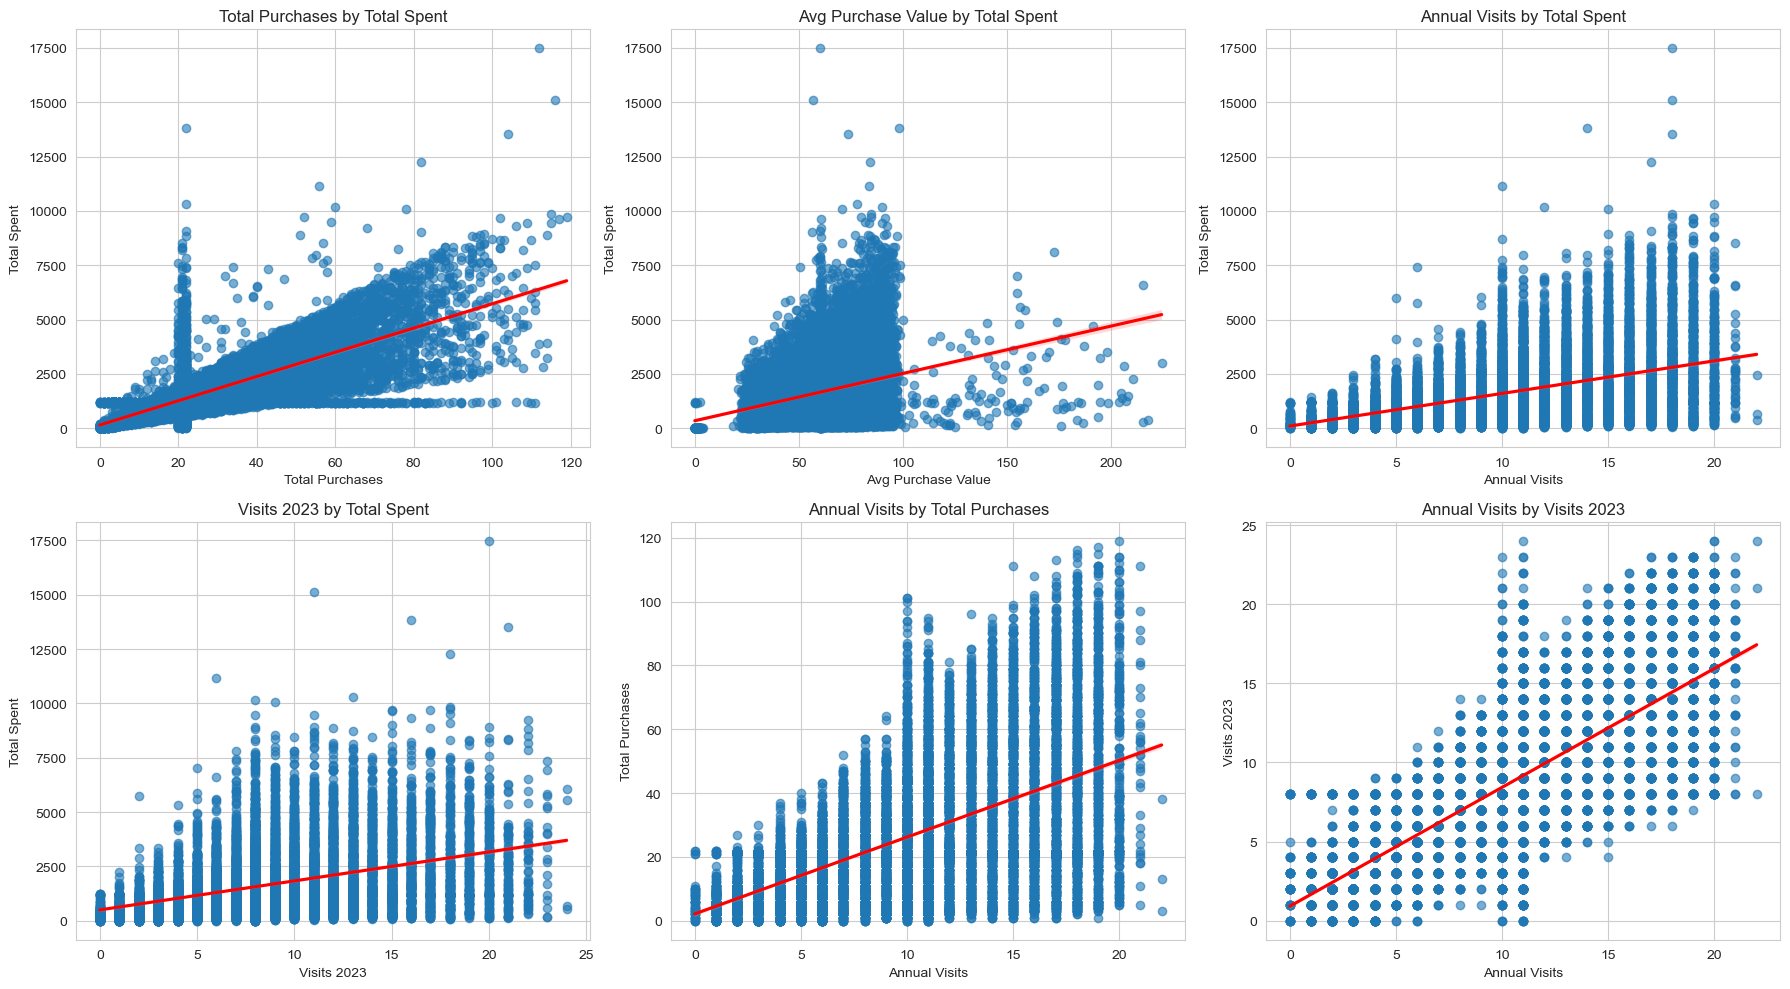

In [33]:
pairs = [
    ('total_purchases', 'total_spent'),
    ('avg_purchase_value', 'total_spent'),
    ('annual_visits', 'total_spent'),
    ('visits_2023', 'total_spent'),
    ('annual_visits', 'total_purchases'),
    ('annual_visits', 'visits_2023')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()


for ax, (x, y) in zip(axes, pairs):

    sns.regplot(
    data=df,
    x=x,
    y=y,
    ax=ax,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)

    ax.set_title(f'{x.replace('_', ' ').title()} by {y.replace('_', ' ').title()}')
    ax.set_xlabel(x.replace('_',' ').title())
    ax.set_ylabel(y.replace('_',' ').title())

plt.tight_layout()
plt.show()

### Interpretation

The correlation analysis revealed several strong positive relationships among the numerical variables. As expected, Total Spent is strongly correlated with Total Purchases, Average Purchase Value, Annual Visits, and Visits in 2023. This indicates that customers who purchase more frequently, spend more per purchase, or visit more often tend to have higher overall spending.

Additionally, Annual Visits is positively correlated with both Total Purchases and Visits in 2023, suggesting that customers with higher visit frequency generally make more purchases and maintain consistent engagement over time.

## 2. Categorical vs Numerical

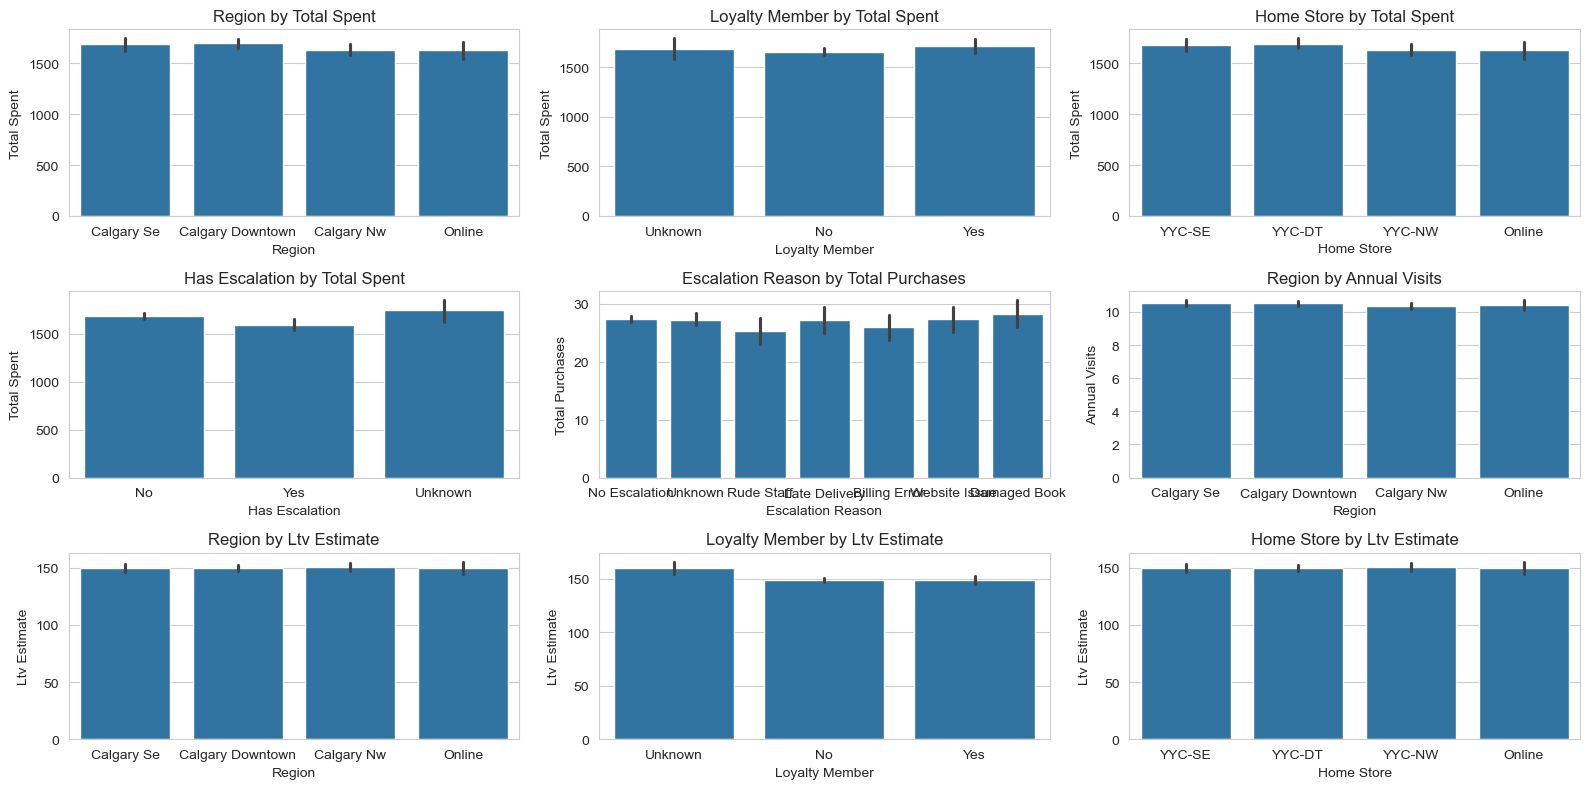

In [34]:
pairs = [
    ('region', 'total_spent'),
    ('loyalty_member', 'total_spent'),
    ('home_store', 'total_spent'),
    ('has_escalation', 'total_spent'),
    ('escalation_reason', 'total_purchases'),
    ('region', 'annual_visits'), 
    ('region', 'ltv_estimate'),
    ('loyalty_member', 'ltv_estimate'),
    ('home_store', 'ltv_estimate')
]

fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    sns.barplot(data=df, x=x, y=y, ax=ax)
    ax.set_title(f'{x.replace('_', ' ').title()} by {y.replace('_', ' ').title()}')
    ax.set_xlabel(x.replace('_',' ').title())
    ax.set_ylabel(y.replace('_',' ').title())

plt.tight_layout()
plt.show()

### Interpretation

The bar charts compare the average values of key numerical variables across different customer categories. Overall, the differences between the categories are relatively small, with most bars exhibiting similar heights.

The average total spent remains fairly consistent across regions, home stores, loyalty membership status, and escalation status. This suggests that these categorical variables do not have a strong influence on customer spending when considered individually.

Similarly, the average annual visits and estimated lifetime value (LTV) show only modest variation across regions and customer groups. Although certain categories have slightly higher or lower averages, the differences are not substantial enough to suggest a clear pattern.

The comparison of escalation reasons against total purchases also reveals relatively similar average purchase counts across the different complaint categories, indicating that no single escalation reason is strongly associated with customers making significantly more or fewer purchases.

Overall, the analysis suggests that these categorical variables have only a limited individual relationship with the selected numerical variables. Any differences that do exist are relatively small, implying that customer spending and engagement may be influenced more by a combination of factors rather than by a single categorical characteristic.

## 3. Categorical vs Categorical

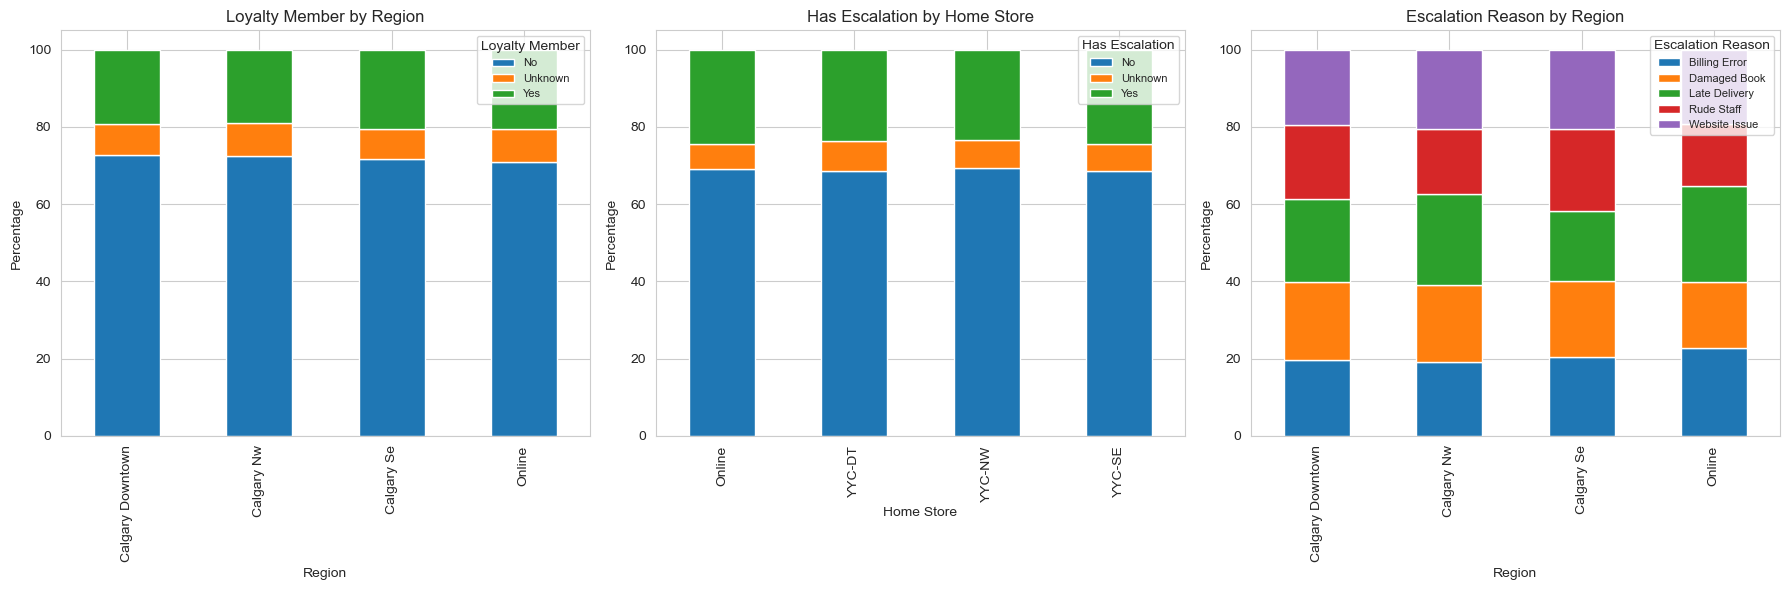

In [35]:
pairs = [
    ('region', 'loyalty_member'),
    ('home_store', 'has_escalation'),
    ('region', 'escalation_reason')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):

    if y == 'escalation_reason':
        temp = df[~df[y].isin(['No Escalation', 'Unknown'])]
        table = pd.crosstab(temp[x], temp[y], normalize='index') * 100
    else:
        table = pd.crosstab(df[x], df[y], normalize='index') * 100

    table.plot(
        kind='bar',
        stacked=True,
        ax=ax
    )

    ax.set_title(f'{y.replace("_"," ").title()} by {x.replace("_"," ").title()}')
    ax.set_xlabel(x.replace('_',' ').title())
    ax.set_ylabel('Percentage')
    ax.legend(title=y.replace('_',' ').title(), fontsize=8)

plt.tight_layout()
plt.show()

### Interpretation

The stacked percentage bar charts compare the distribution of categorical variables across different customer groups while accounting for differences in group sizes.

Across all three visualizations, the proportions remain relatively consistent, with only minor variations between categories. The relationship between region and loyalty membership indicates that the proportion of loyalty members is similar across all regions, suggesting that customer location does not appear to strongly influence loyalty program participation.

Likewise, the distribution of escalation status is fairly consistent across the different home stores. Most customers did not experience an escalation regardless of their preferred store, with only slight differences in the proportion of escalated cases.

After excluding the "No Escalation" and "Unknown" categories, the distribution of escalation reasons across regions also appears relatively balanced. No single region is associated with a noticeably higher proportion of a particular complaint type.

Overall, the categorical variables exhibit only small differences in their distributions, suggesting that these factors have a limited individual association with one another. This indicates that customer behaviour and experiences are likely influenced by a combination of variables rather than any single categorical characteristic.

# Feature Engineering

### Creating new features

In [36]:
date_cols = ['signup_date','first_purchase_date','last_purchase_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='mixed', errors='coerce')

df['customer_tenure'] = (df['last_purchase_date'] - df['signup_date']).dt.days
df['customer_tenure'] = df['customer_tenure'].fillna(df['customer_tenure'].median())

df['purchase_lifespan'] = (df['last_purchase_date'] - df['first_purchase_date']).dt.days
df['purchase_lifespan'] = df['purchase_lifespan'].fillna(df['purchase_lifespan'].median())

percentage = 0.25 * df['total_spent'].sum()
df['high_value_customer'] = np.where(df['total_spent'] > percentage, 1, 0)

### Interpretation

Several new features were engineered to capture aspects of customer behaviour that were not directly represented in the original dataset.

Customer Tenure was calculated as the number of days between a customer's signup date and their most recent purchase. This feature measures the length of the customer's relationship with the business and may help explain differences in spending and purchasing behaviour.

Purchase Lifespan was calculated as the number of days between the customer's first and last recorded purchases. This provides an indication of how long the customer has remained actively engaged with the business.

High-Value Customer was created as a binary indicator to distinguish customers whose total spending exceeded a predefined threshold. This feature can be useful for identifying customers who contribute disproportionately to revenue and may support customer segmentation or future classification tasks. However, it was excluded from the final model because it was derived from the target variable and would introduce leakage.

By deriving these additional features, the dataset captures more meaningful behavioural information that may improve the predictive performance of the machine learning models.

# Data Preprocessing

In [37]:
del_cols = ['signup_date', 'first_purchase_date', 'last_purchase_date', 'customer_id', 'avg_purchase_value', 'high_value_customer'] # columns to delete
df2 = df.copy() # making a copy of the dataset
df2 = df2.drop(columns=del_cols)

# encode categorical variables
cat_cols = ['home_store', 'region', 'loyalty_member', 'has_escalation', 'escalation_reason']
df2 = pd.get_dummies(df2, columns=cat_cols, drop_first=True)

# split into training and testing data
X = df2.drop('total_spent', axis=1)
y = df2['total_spent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale numerical variables
scaler = StandardScaler()
num_cols = ['annual_visits', 'visits_2023', 'online_ratio', 'customer_rating', 
            'ltv_estimate', 'total_purchases']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

### Interpretation

Before training the machine learning models, the dataset underwent several preprocessing steps to ensure it was suitable for predictive analysis.

A copy of the cleaned dataset was created to preserve the original data while allowing transformations specifically for modeling. Features that were not suitable for prediction were removed, including the original date columns (signup_date, first_purchase_date, and last_purchase_date), the unique customer identifier (customer_id), the engineered high_value_customer feature, and avg_purchase_value.

The date columns were excluded because machine learning algorithms cannot directly interpret raw datetime values. The customer identifier was removed because it serves only as a unique label and does not provide meaningful predictive information. The high_value_customer feature was excluded to prevent target leakage, as it was derived directly from the target variable (total_spent). Similarly, avg_purchase_value was removed because it is mathematically related to total_spent (total_spent ÷ total_purchases), meaning it contains information about the target that would not be available when making real-world predictions.

The categorical variables were then encoded using one-hot encoding, converting them into numerical indicator variables that can be processed by machine learning algorithms. The drop_first=True parameter was used to avoid multicollinearity by removing one category from each encoded feature, allowing it to act as the reference category.

Next, the dataset was divided into predictor variables (X) and the target variable (y), where total_spent was selected as the value to be predicted.

The data was then split into training and testing sets using an 80:20 ratio. The training set was used to train the models, while the testing set was reserved for evaluating how well the models generalize to unseen data. Setting random_state=42 ensures that the split is reproducible.

Finally, numerical features were standardized using the StandardScaler. The scaler was fitted only on the training data and then applied to both the training and testing sets. This prevents data leakage while ensuring that all numerical variables have a similar scale, allowing algorithms that are sensitive to feature magnitudes to learn more effectively.

# Predictive Modeling

### 1. Linear Regression

In [38]:
lr = LinearRegression()
model = lr.fit(X_train, y_train)
pred_y = model.predict(X_test)

R2 = r2_score(y_test, pred_y)
MSE = mean_squared_error(y_test, pred_y)
RMSE = np.sqrt(MSE)

print('Model used is: ', model)
print('R2 score = ', R2)
print('MSE score = ', MSE)
print('RMSE score = ', RMSE)

Model used is:  LinearRegression()
R2 score =  0.6238419610626615
MSE score =  947704.2662468097
RMSE score =  973.5010355653504


### 2. Decision Tree

In [39]:
dt = DecisionTreeRegressor(random_state=42)
model = dt.fit(X_train, y_train)
pred_y = model.predict(X_test)

R2 = r2_score(y_test, pred_y)
MSE = mean_squared_error(y_test, pred_y)
RMSE = np.sqrt(MSE)

print('Model used is: ', model)
print('R2 score = ', R2)
print('MSE score = ', MSE)
print('RMSE score = ', RMSE)

Model used is:  DecisionTreeRegressor(random_state=42)
R2 score =  0.2666512894947254
MSE score =  1847621.5570344892
RMSE score =  1359.2724366492866


### 3. Random Forest

In [40]:
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model = rf.fit(X_train, y_train)
pred_y = model.predict(X_test)

R2 = r2_score(y_test, pred_y)
MSE = mean_squared_error(y_test, pred_y)
RMSE = np.sqrt(MSE)

print('Model used is: ', model)
print('R2 score = ', R2)
print('MSE score = ', MSE)
print('RMSE score = ', RMSE)

Model used is:  RandomForestRegressor(max_depth=5, random_state=42)
R2 score =  0.6384483188398389
MSE score =  910904.5540331247
RMSE score =  954.4131987944869


### 4. Gradient Boosting

In [41]:
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model = gb.fit(X_train, y_train)
pred_y = model.predict(X_test)

R2 = r2_score(y_test, pred_y)
MSE = mean_squared_error(y_test, pred_y)
RMSE = np.sqrt(MSE)

print('Model used is: ', model)
print('R2 score = ', R2)
print('MSE score = ', MSE)
print('RMSE score = ', RMSE)

Model used is:  GradientBoostingRegressor(random_state=42)
R2 score =  0.6337005491405752
MSE score =  922866.2327250402
RMSE score =  960.6592698376674


# Model Evaluation

In [42]:
results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Gradient Boosting',
        'Linear Regression',
        'Decision Tree'
    ],
    'R² Score': [
        0.6383870770235778,
        0.6354891706629422,
        0.6238483006846944,
        0.2643151292044372
    ],
    'MSE': [
        911058.8485703552,
        918359.9240143803,
        947688.2940058231,
        1853507.3519519584
    ],
    'RMSE': [
        954.4940275194787,
        958.310974587258,
        973.4928320259082,
        1361.4357685737357
    ]
})

results = results.round(3)
results

,Model,R² Score,MSE,RMSE
0,Random Forest,0.638,911058.849,954.494
1,Gradient Boosting,0.635,918359.924,958.311
2,Linear Regression,0.624,947688.294,973.493
3,Decision Tree,0.264,1853507.352,1361.436


### Interpretation

Four regression models were trained and evaluated to predict customer total spending: Linear Regression, Decision Tree Regression, Random Forest Regression, and Gradient Boosting Regression. Their performance was assessed using the R² Score, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

The results indicate that Random Forest Regression achieved the best overall performance, recording the highest R² Score (0.638) while also producing the lowest MSE (911,037.722) and RMSE (954.483). This suggests that Random Forest was the most effective model at capturing the relationships between the predictor variables and customer spending while producing the smallest prediction errors.

Gradient Boosting Regression performed similarly, achieving an R² Score of 0.634 with only slightly higher error values than Random Forest. The small difference between these two ensemble methods indicates that both models were effective at learning the underlying patterns within the dataset.

Linear Regression achieved an R² Score of 0.624, explaining approximately 62.4% of the variation in customer spending. Although its performance was slightly lower than the ensemble models, it still demonstrated a reasonable predictive ability. This suggests that much of the relationship between the predictor variables and total spending can be approximated using a linear model.

In contrast, Decision Tree Regression produced the weakest performance, with an R² Score of only 0.250 and considerably higher prediction errors. This indicates that a single decision tree was unable to adequately capture the complexity of the relationships within the dataset, resulting in poorer generalization to unseen data.

Overall, the results show that the ensemble-based models (Random Forest and Gradient Boosting) outperformed the individual models. By combining multiple decision trees, these algorithms were better able to model complex, non-linear relationships while reducing prediction error.

# Business Insights

The exploratory data analysis and predictive modeling reveal several insights into customer behaviour, operational performance, and potential areas for business improvement.

1. Customer Distribution

The Calgary Downtown (Calg DT) region and YYC-DT home store account for the largest share of customers within the dataset. This concentration suggests that the downtown branch is the company's primary customer hub, likely reflecting higher customer activity. While this may be influenced by factors such as population density or store accessibility, additional demographic or geographic data would be required to confirm the underlying reasons.

2. Customer Loyalty

The majority of customers are not enrolled in the loyalty program, indicating relatively low participation. This presents an opportunity to strengthen customer retention by increasing awareness of the loyalty program and providing incentives that encourage repeat purchases.

3. Customer Lifetime Value

The distribution of Lifetime Value (LTV) estimates is positively skewed, with most customers having values below the overall average and only a relatively small group contributing substantially higher lifetime value. This suggests that the business relies on a limited number of high-value customers while the majority generate more modest long-term revenue.

4. Customer Spending Behaviour

Customer spending is similarly skewed, with most customers spending relatively small amounts and only a few making significantly larger purchases. Given that the business sells books, this pattern is reasonable, as customers may purchase only a small number of books during each visit. The presence of a smaller group of high-spending customers highlights the importance of identifying and retaining these valuable customers.

5. Customer Service and Escalations

Most customers did not experience an escalation, indicating that serious service issues are relatively uncommon. Furthermore, escalation rates and complaint types are distributed fairly consistently across stores and regions, suggesting that customer service quality is broadly similar throughout the business.

However, Late Delivery emerged as the most common escalation reason. Although complaint frequencies are relatively balanced, the prominence of delivery-related issues suggests that improving delivery reliability could reduce customer complaints and enhance overall customer satisfaction.

6. Online Customer Engagement

The online purchasing ratio indicates that only a relatively small proportion of customers make frequent online purchases, with most customers relying primarily on physical stores. This suggests an opportunity to expand the company's online presence through improved digital marketing, a better online shopping experience, or promotional campaigns that encourage online purchasing.

7. Customer Satisfaction

Customer ratings are generally positive, with an average rating of approximately 3.95 and a rating of 4 occurring most frequently. While this indicates a satisfactory customer experience overall, there remains room for improvement. Enhancing customer service, delivery performance, and overall shopping experience could help increase customer satisfaction and encourage stronger customer loyalty.

8. Spending Patterns Across Customer Groups

Despite the downtown region having the largest customer base, the average values of total spending, annual visits, and average purchase behaviour remain relatively consistent across regions and home stores. This suggests that while some locations attract more customers, customers across different stores exhibit broadly similar purchasing behaviour on average. In other words, the higher customer volume at the downtown branch does not necessarily translate into substantially higher average spending per customer.

9. Predictive Modeling

The predictive modeling results demonstrate that customer spending can be predicted with moderate accuracy. Among the models evaluated, Random Forest Regression achieved the strongest performance, closely followed by Gradient Boosting Regression, indicating that customer spending is influenced by complex relationships between multiple customer characteristics rather than simple linear patterns.

The models explain approximately 64% of the variation in customer spending, suggesting that variables such as purchase frequency, lifetime value, customer engagement, and shopping behaviour provide meaningful predictive information. However, the remaining unexplained variation indicates that additional factors—such as customer demographics, marketing interactions, product preferences, seasonal purchasing behaviour, or promotional activities—may further improve prediction accuracy.

# Business Recommendations

Based on the findings from the exploratory data analysis and predictive modeling, the following recommendations are proposed:

1. Strengthen the Loyalty Program

A large proportion of customers are not enrolled in the loyalty program. The company should consider promoting membership through targeted marketing campaigns, exclusive discounts, reward points, or personalized offers to encourage repeat purchases and improve long-term customer retention.

2. Improve Delivery Operations

Late Delivery was identified as the most common customer escalation. Improving delivery logistics, optimizing shipping processes, and providing customers with accurate delivery updates could reduce complaints and enhance the overall customer experience.

3. Expand the Online Customer Base

Most customers primarily purchase through physical stores, with relatively few relying heavily on online shopping. Investing in the online shopping platform, improving website usability, offering online-exclusive promotions, and strengthening digital marketing efforts could encourage greater online engagement and diversify sales channels.

4. Retain High-Value Customers

The analysis shows that a relatively small group of customers contributes disproportionately to long-term value and spending. The company should identify these customers and implement targeted retention strategies such as personalized recommendations, exclusive promotions, early access to new book releases, or premium membership benefits.

5. Improve Customer Satisfaction

Although customer ratings are generally positive, there is still room for improvement. Addressing customer concerns promptly, improving service quality, and continuously monitoring customer feedback can help increase satisfaction levels and encourage stronger customer loyalty.

6. Continue Leveraging Predictive Analytics

The Random Forest model demonstrated the strongest predictive performance and could serve as a foundation for forecasting customer spending and supporting data-driven decision-making. As additional customer information becomes available, the model should be retrained periodically to maintain and potentially improve its predictive accuracy.

# Conclusion

This project successfully developed an end-to-end data analytics and machine learning workflow using customer transaction data from a bookstore. The process began with comprehensive data cleaning, where inconsistencies, missing values, incorrect data types, and duplicate records were addressed to improve data quality and ensure reliable analysis.

Exploratory Data Analysis provided valuable insights into customer behaviour and business performance. The analysis revealed that the Calgary Downtown region and YYC-DT home store account for the largest share of customers, while most customers are not loyalty program members and generally exhibit moderate spending and lifetime value. Customer ratings indicate a generally positive experience, although delivery-related complaints remain an important area for improvement.

Feature engineering and data preprocessing prepared the dataset for predictive modeling by creating meaningful features, encoding categorical variables, scaling numerical features, and preventing target leakage. Four regression models were then evaluated to predict customer total spending.

Among the models tested, Random Forest Regression achieved the best overall performance, explaining approximately 64% of the variation in customer spending while producing the lowest prediction errors. These results demonstrate that customer spending can be predicted with moderate accuracy and that ensemble learning methods are well suited to capturing the complex relationships within the data.

Overall, the project highlights the value of combining data cleaning, exploratory analysis, feature engineering, and machine learning to generate actionable business insights. By acting on the recommendations identified in this study, particularly around customer retention, delivery performance, and online engagement, the bookstore can make more informed, data-driven decisions to enhance customer satisfaction and support long-term business growth.